##Контрольная работа №3

ФИО
ИД24-3

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error,mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve

1.(1 балл) Загрузите предложенный вам датасет с помощью функции sklearn.datasets.fetch_openml. Выведите текстовое описание загруженного датасета. Определите какая бизнес-задача ставится. Переведите бизнес-задачу в задачу машинного обучения.

In [22]:
eff = fetch_openml('energy_efficiency', version=2)

In [23]:
print(eff.DESCR)

**Source**

This dataset was obtained from the UCI Repository.

The dataset was created by Angeliki Xifara (angxifara '@' gmail.com, Civil/Structural Engineer) and was processed by Athanasios Tsanas (tsanasthanasis '@' gmail.com, Oxford Centre for Industrial and Applied Mathematics, University of Oxford, UK).
Data Set Information:
We perform energy analysis using 12 different building shapes simulated in Ecotect. The buildings differ with respect to the glazing area, the glazing area distribution, and the orientation, amongst other parameters. We simulate various settings as functions of the afore-mentioned characteristics to obtain 768 building shapes. The dataset comprises 768 samples and 8 features, aiming to predict two real valued responses. It can also be used as a multi-class classification problem if the response is rounded to the nearest integer.

**Attribute Information**

The dataset contains eight attributes and two responses. In the original data, the aim is to use the eig

В датасете проводится энергетический анализ 12 различных форм зданий, смоделированных в Ecotect. Здания различаются по площади остекления, распределению площади остекления и ориентации, а также по другим параметрам. Различные параметры моделируются в зависимости от вышеупомянутых характеристик, чтобы получить 768 форм зданий. Набор данных содержит 768 объектов и 8 признаков, предназначенных для прогнозирования двух вещественных значений. Он также может использоваться в качестве задачи многоклассовой классификации, если значение округлено до ближайшего целого числа.

**Информация об атрибутах и бизнес-задаче**

Набор данных содержит восемь атрибутов. Бизнес-задача состоит в прогнозировании тепловой нагрузки. Тк тепловая нагрузка принимает непрерывные числовые значения, задача машинного обучения - регрессия


2. (1 балл) Проведите предварительный анализ датасета. Выведите основную статистическую информацию о данных. Проверьте дисбаланс целевого признак



In [24]:
eff = eff.frame
eff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   relative_compactness       768 non-null    float64
 1   surface_area               768 non-null    float64
 2   wall_area                  768 non-null    float64
 3   roof_area                  768 non-null    float64
 4   overall_height             768 non-null    float64
 5   orientation                768 non-null    int64  
 6   glazing_area               768 non-null    float64
 7   glazing_area_distribution  768 non-null    int64  
 8   heating_load               768 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 54.1 KB


In [25]:
eff.describe()


,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution,heating_load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000


In [30]:
y = eff['heating_load']
X = eff.drop('heating_load', axis=1)
X.shape, y.shape

((768, 8), (768,))

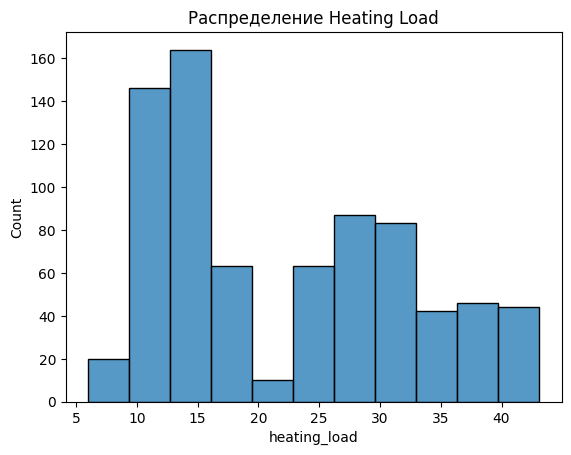

In [33]:
sns.histplot(y)
plt.title('Распределение Heating Load')
plt.show()

Гистограмма показывает, что данные распределены неравномерно и линейные модели будут плохо предсказывать значения

3.(1 балл) Убедитесь, что данные пригодны для моделирования. В данных не должно быть пропущенных значений, все признаки должны быть численными. Если эти условия нарушаются, исправьте это.

In [34]:
eff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   relative_compactness       768 non-null    float64
 1   surface_area               768 non-null    float64
 2   wall_area                  768 non-null    float64
 3   roof_area                  768 non-null    float64
 4   overall_height             768 non-null    float64
 5   orientation                768 non-null    int64  
 6   glazing_area               768 non-null    float64
 7   glazing_area_distribution  768 non-null    int64  
 8   heating_load               768 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 54.1 KB


Все признаки численные, пропущенных значений нет

4.(1 балл) Обучите любую линейную модель, которая решает поставленную задачу. Выведите с помощью метода score() результат метрики оценки модели. Опишите какая метрика подсчитывается в методе score().

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f'Score:{model.score(X_test, y_test)}')


Score:0.9121846294352439


Score - коэффициент детерминации, показывает долю распределения значений целевой переменной, верно предскзанную моделью

5.(1 балл) К поставленной задачи машинного обучения подберите еще 3 метрики. С помощью их оцените обученную линейную модель.

In [41]:
mae= mean_absolute_error(y_test, y_pred)
mse = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')

MAE: 2.1820729961538947
MSE: 2.1820729961538947
RMSE: 3.025426853510372


6.(1 балл) Для задач регрессии: Постройте совместное распределение теоретических и эмпирических значений целевой переменной. Сделайте вывод о наличии либо отсутствии систематической компоненты в отклонениях, их общей величине.

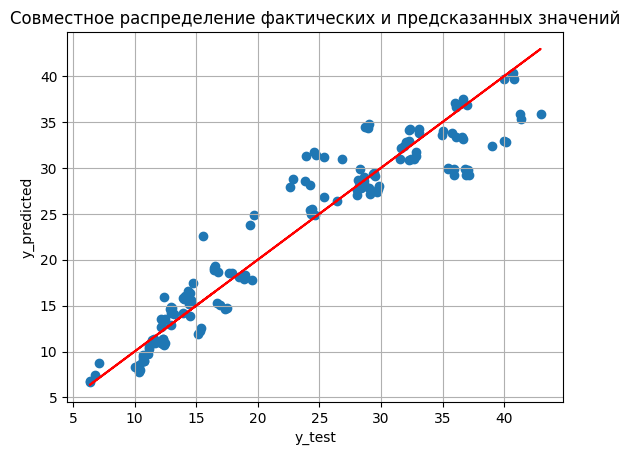

In [45]:
plt.scatter(y_test, y_pred)
plt.plot(y_test,y_test, color='r')
plt.xlabel('y_test')
plt.ylabel('y_predicted')
plt.title('Совместное распределение фактических и предсказанных значений')
plt.grid(True)
plt.show()

В отклонениях присутствует систематическая компонента, особенно на краях распределения. В области высоких значений (35–43) модель занижает предсказания для самых энергозатратных зданий.
В области средних значений (25–30) наблюдается небольшое завышение — группа точек смещена выше линии.
Общая величина отклонений умеренная

7.(1 балл) Для задач регрессии: Постройте ту же модель, но с предварительной нормализацией значений признаков. Сделайте вывод о влиянии нормализации на качество работы модели.

In [49]:
scaled = make_pipeline(StandardScaler(), LinearRegression())
scaled.fit(X_train, y_train)
print(scaled.score(X_test, y_test))

0.9121846294352439


Нормализация признаков не оказала существенного влияния на качество работы линейной модели (метрика r2 осталась неизменной). Это объясняется тем, что  метод наименьших квадратов не чувствителен к линейному масштабированию признаков

8.(1 балл) Обоснуйте выбор типа разбиения данных при кросс-валидации для вашей задачи машинного обучения. Обучите любую другую модель используя кросс-валидацию данных.

Данный датасет относительно небольшой (768 записей) поэтому для него подходит k-fold kross-validation

In [52]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=kf, scoring='r2')
print(f"Значения r2 для каждого фолда: {cv_scores}")
print(f"Среднее значение r2: {np.mean(cv_scores)}")
print(f"Стандартное отклонение: {np.std(cv_scores)}")

Значения r2 для каждого фолда: [0.9977673  0.99803413 0.99787546 0.99768378 0.99751577]
Среднее значение r2: 0.9977752873518684
Стандартное отклонение: 0.00017482600320078244


9.(2 балл) Проведите диагностику любой модели. Постройте кривые обучения. Сделайте вывод о переобученности или недообученности модели.

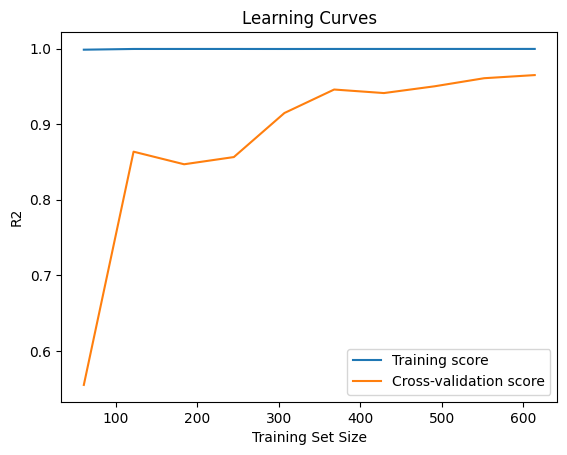

In [57]:
train_sizes, train_scores, test_scores = learning_curve(RandomForestRegressor(), X, y, train_sizes = np.linspace(0.1, 1.0, 10))
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label='Training score')
plt.plot(train_sizes, test_mean, label='Cross-validation score')
plt.title('Learning Curves')
plt.xlabel('Training Set Size')
plt.ylabel('R2')
plt.legend()
plt.show()

К концу графика разрыв между обучающей и тестовой выборкой минимальный,значит, модель работает хорошо как и на тренировочных данных, так и с новыми значениями

10.(2 балл) Исследуйте как любой из гиперпараметров модели влияет на эффективность модели.

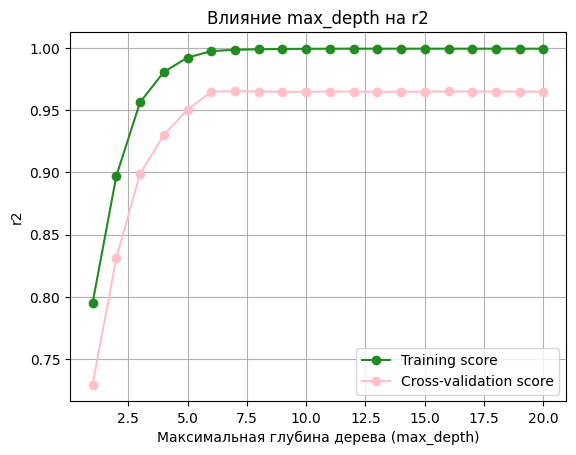

In [60]:
from numpy.random import random_integers
param_range = np.arange(1, 21)
train_scores, test_scores=validation_curve(RandomForestRegressor(), X, y, param_name='max_depth', param_range=param_range, cv=5, scoring='r2', n_jobs=-1)
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(param_range, train_mean, label="Training score", color="forestgreen", marker='o')
plt.plot(param_range, test_mean, label="Cross-validation score", color="pink", marker='o')
plt.title("Влияние max_depth на r2")
plt.xlabel("Максимальная глубина дерева (max_depth)")
plt.ylabel("r2")
plt.legend(loc="best")
plt.grid(True)
plt.show()

Варианты students_scores wholesale-customers pc1_req vertebra-column prnn_crabs cloud fertility ricci_vs_destefano machine_cpu lupus energy-efficiency LED-display-domain-7digit diggle_table_a2 ecoli breast-tissue prnn_fglass confidence glass user-knowledge olindda_outliers